# Microbiome illustration experiments

We consider the gnotobiotic mice dataset of [Bucci et al. (2016)](https://doi.org/10.1186/s13059-016-0980-6). The dataset consists in $5$ gut-engineered mice which are affected by 2 perturbations: a gut colonization at initial time, and an infection with *C. difficile* at timepoint $t=13$.

The goal is to identify independent components of co-varying microbial taxa in the gut microbiome of mice undergoing the infection.
Results highlight biologically relevant components, as well as perturbation models aligned with clinical perturbations.

The notebook also includes an auxiliary forecasting experiment, showing the capacity of ARPLN-ICA to forecast temporal count data comparatively to standard approaches.

# Importing data

First we import the dataset and visualise the multivariate time series.

In [1]:
import numpy as np
import pandas as pd
import torch
from plntime.models.plnica import PLNICA

# Loading counts
longitudinal_data = pd.read_csv('plntime/data/bucci_gnotobiotic_mice/longitudinal_data.csv').set_index('sampleID')
longitudinal_data[longitudinal_data.Mouse == 4]
longitudinal_data = longitudinal_data[['Mouse', 'Time', 'Clostridium-scindens', 'Bacteroides-ovatus', 'Parabacteroides-distasonis', 'Akkermansia-muciniphila', 'Roseburia-hominis', 'Clostridium-difficile', 'Clostridium-ramosum', 'Proteus-mirabilis', 'Escherichia-coli', 'Bacteroides-fragilis', 'Bacteroides-vulgatus', 'Ruminococcus-obeum', 'Klebsiella-oxytoca']]
longitudinal_data

,Mouse,Time,Clostridium-scindens,Bacteroides-ovatus,Parabacteroides-distasonis,Akkermansia-muciniphila,Roseburia-hominis,Clostridium-difficile,Clostridium-ramosum,Proteus-mirabilis,Escherichia-coli,Bacteroides-fragilis,Bacteroides-vulgatus,Ruminococcus-obeum,Klebsiella-oxytoca
sampleID,,,,,,,,,,,,,,,
1,1,0.75,1065,7454,38,813,5,0,3259,1330,2938,3391,20904,30,22068
2,1,1.00,460,16240,76,5942,90,0,4548,1327,2794,4339,17861,408,18049
3,1,2.00,199,22250,166,27211,1515,0,5325,1092,2651,5116,8817,1405,8956
4,1,3.00,98,10575,445,17139,1057,0,3172,726,997,1791,2670,312,2748
5,1,4.00,209,18852,878,22484,1557,0,5956,1271,2315,3846,4706,754,1728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,5,42.00,92,13708,785,19938,1272,1089,6284,1118,447,7146,6269,1636,852
127,5,45.00,88,14503,1325,19328,1146,882,4804,1120,602,7139,4003,1267,1137
128,5,49.00,122,15862,1534,25861,1170,816,4053,657,1579,7504,3526,1012,1313


In [2]:
# Loading metadata
metadata = pd.read_csv('plntime/data/bucci_gnotobiotic_mice/metadata.txt', sep='\t')

Data shape: torch.Size([5, 26, 13])


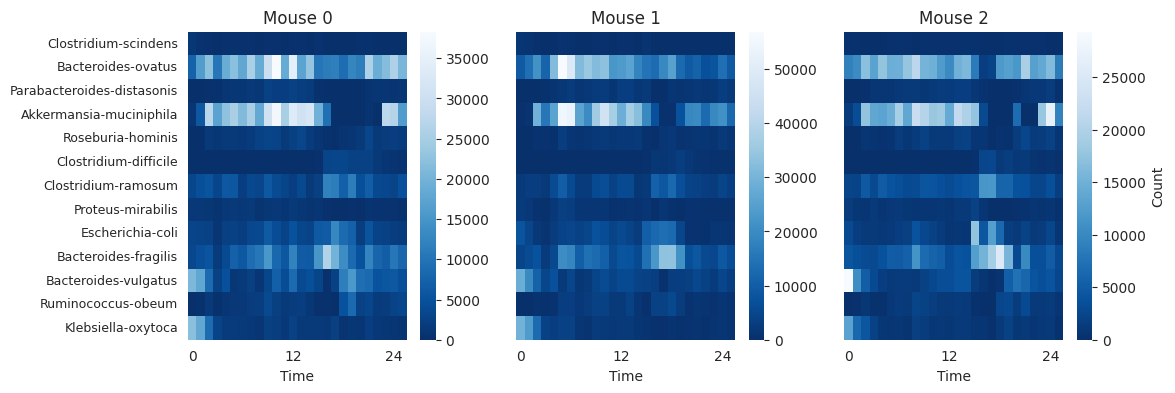

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_style('whitegrid')

taxa_names = longitudinal_data.columns[2:]
n = len(np.unique(longitudinal_data['Mouse']))
T = len(np.unique(longitudinal_data[longitudinal_data['Mouse'] == 1].Time))
K = len(taxa_names)

X = torch.zeros(n, T, K)

# Creating dataset
for i, mouse_i in enumerate(np.unique(longitudinal_data['Mouse'])):
    for k, t in enumerate(np.unique(longitudinal_data[longitudinal_data['Mouse'] == mouse_i].Time)):
        X[i, k, :] = X[i, k, :] + torch.tensor(longitudinal_data[(longitudinal_data['Mouse'] == mouse_i) & (longitudinal_data['Time'] == t)][taxa_names].to_numpy().squeeze())

print('Data shape:', X.shape)

fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for i, s in enumerate(range(3)):
    ax = axs[i]
    sns.heatmap(X[i].T, cmap="Blues_r", ax=ax, cbar_kws={'label': 'Count'} if i == 2 else None, linewidths=0.0, rasterized=True)
    ax.set_xlabel('Time')
    ax.set_xticklabels([int(x) if int(x) in [0, 12, 24] else '' for x in ax.get_xticks()], rotation=0.)
    ax.set_yticks(np.arange(0, len(taxa_names))+0.5)
    ax.set_yticklabels(taxa_names, fontsize=9, rotation=0)
    #plt.ylabel("Bacteria")
    ax.set_title(f"Mouse {i}")
    ax.grid(False)

plt.savefig('./figures/mice_time_series.pdf', bbox_inches='tight')

# Functions for model evaluation

These functions are used across the notebook to compute statistics on the data or perform preprocessing.

In [4]:
def clr(X):
    """
    Centered log-ratio transform
    """
    X_log = torch.log(X + 0.5)
    return X_log - X_log.mean(dim=-1, keepdim=True)

def offset(X):
    """
    Offset computation from X
    """
    return torch.log(X.sum(dim=-1) + 1)

In [5]:
def average_poisson_deviance(X_test, X_pred, eps = 1e-8, reduction = "mean"):
    """
    Average Poisson deviance for counts y and Poisson mean mu.

    Deviance per entry:
        D = 2 * ( y * log(y / mu) - (y - mu) )
    with the convention y*log(y/mu) := 0 when y = 0.
    """
    y = X_test.to(dtype=torch.float32)
    mu = X_pred.to(dtype=torch.float32).clamp_min(eps)

    # term y * log(y/mu), safe at y=0
    y_over_mu = (y / mu).clamp_min(eps)
    log_term = torch.where(y > 0, y * torch.log(y_over_mu), torch.zeros_like(y))

    dev = 2.0 * (log_term - (y - mu))

    if reduction == "mean":
        return dev.mean()
    if reduction == "sum":
        return dev.sum()
    if reduction == "none":
        return dev
    raise ValueError(f"Unknown reduction={reduction!r}")


def mae_log1p(X_test, X_pred, reduction = "mean"):
    """
    MAE computation, averaged through time and features
    """
    y = X_test.to(dtype=torch.float32)
    yhat = X_pred.to(dtype=torch.float32)

    err = torch.abs(torch.log1p(y) - torch.log1p(yhat))

    if reduction == "mean":
        return err.mean()
    if reduction == "sum":
        return err.sum()
    if reduction == "none":
        return err
    raise ValueError(f"Unknown reduction={reduction!r}")


def mean_aitchison_distance(X_test, X_pred, pseudocount = 0.5, reduction = "mean"):
    """
    Aitchison distance, averaged through time and features
    """
    y = X_test.to(dtype=torch.float32)
    yhat = X_pred.to(dtype=torch.float32)

    y = y + pseudocount
    yhat = yhat + pseudocount

    p = y / y.sum(dim=-1, keepdim=True).clamp_min(1e-12)
    q = yhat / yhat.sum(dim=-1, keepdim=True).clamp_min(1e-12)

    logp = torch.log(p.clamp_min(1e-12))
    logq = torch.log(q.clamp_min(1e-12))

    clrp = logp - logp.mean(dim=-1, keepdim=True)
    clrq = logq - logq.mean(dim=-1, keepdim=True)

    dist = torch.linalg.norm(clrp - clrq, dim=-1)  # (n, T)

    if reduction == "mean":
        return dist.mean()
    if reduction == "sum":
        return dist.sum() 
    if reduction == "none":
        return dist
    raise ValueError(f"Unknown reduction={reduction!r}")

# Plot functions

These functions are used across the notebook for the plots.

In [6]:
import math
from matplotlib.patches import Patch
import cmasher

def barplot_per_metric(metrics, model_colors = None, metric_names = None, ncols = 3, figsize = None, show_xticklabels = False, rotate_xticklabels = 20, deviance_log = False, cmap=plt.colormaps.get_cmap('plasma'), ncols_legend=5, ylegend=0.):
    if not metrics:
        raise ValueError("`metrics` is empty.")

    model_names = list(metrics.keys())

    # Pick metrics to plot
    if metric_names is None:
        all_cols = set()
        for df in metrics.values():
            all_cols |= set(df.columns)
        metric_names = sorted(all_cols)
    else:
        metric_names = list(metric_names)

    n_metrics = len(metric_names)
    if n_metrics == 0:
        raise ValueError("No metric columns found to plot.")

    # Colors
    if model_colors is None:
        model_colors = {
            model: cmap((i+1)/len(metrics)) for i, model in enumerate(metrics)
        }

    # Subplot grid
    nrows = math.ceil(n_metrics / ncols)
    if figsize is None:
        figsize = (4.2 * ncols, 3.2 * nrows)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False)
    axes_flat = axes.ravel()

    for i, metric in enumerate(metric_names):
        ax = axes_flat[i]

        means = []
        stds = []
        for m in model_names:
            df = metrics[m]
            if metric in df.columns:
                vals = df[metric].dropna().to_numpy()
            else:
                vals = np.array([])

            if vals.size == 0:
                mu = np.nan
                sd = np.nan
            elif vals.size == 1:
                mu = float(vals[0])
                sd = 0.0
            else:
                mu = float(np.mean(vals))
                sd = float(np.std(vals, ddof=1))  # std across folds

            means.append(mu)
            stds.append(sd)

        x = np.arange(1, len(model_names) + 1)

        bar_colors = [model_colors[m] for m in model_names]
        ax.bar(
            x, means,
            yerr=stds,
            color=bar_colors,
            edgecolor="black",
            linewidth=1.0,
            alpha=0.85,
            error_kw=dict(elinewidth=1.2, capsize=3, capthick=1.2, ecolor='#333333'),
        )

        ax.set_ylabel(metric)
        ax.grid(axis="y", alpha=0.25)
        ax.grid(axis='x', alpha=0.)

        ax.set_xticks(x)
        if show_xticklabels:
            ax.set_xticklabels(model_names, rotation=rotate_xticklabels, ha="right")
        else:
            ax.set_xticklabels([])

        if 'deviance' in metric and deviance_log:
            ax.set_yscale('log')

    # Hide unused axes if grid larger than needed
    for j in range(n_metrics, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Shared legend (below the whole figure)
    legend_handles = [Patch(facecolor=model_colors[m], edgecolor="black", label=m, alpha=0.85) for m in model_names]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=ncols_legend,
        frameon=True,
        bbox_to_anchor=(0.5, ylegend),
    )

    # Leave room for legend
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.12)
    sns.despine(fig)

    return fig, axes

# Regime modeling and ICA

## Effect of the number of sources

First we look into the effect of $d$ on the recovered components; mostly in terms of reconstruction fidelity.

In [7]:
import torch
from plntime.models.plnica import PLNICA
import numpy as np
from sklearn.model_selection import LeaveOneOut
import matplotlib as mpl
import pickle
import os

seed=42

params = dict(
    amortized_size=10,
    n_layers_amortizer=3,
    n_output_layers_amortizer=1,
    shared_network_size=[32, 16],
    n_output_layers_shared=2
)

d_list = [3, 4, 5, 7, 10, 13]
C = 2

plnica_dic = {}
elbo_dic = {}
loo = LeaveOneOut()

path_plnica = './cache/reconstruction/plnica_dic.pkl'
path_elbo = './cache/reconstruction/elbo_dic.pkl'
if os.path.isfile(path_plnica):
    print('loaded')
    with open(path_plnica, 'rb') as f:
        plnica_dic = pickle.load(f)
    with open(path_elbo, 'rb') as f:
        elbo_dic = pickle.load(f)
else:
    for d in d_list:
        print('Dimension', d)
        plnica_dic[d] = {}
        elbo_dic[d] = {}
        for i, (train_index, test_index) in enumerate(loo.split(X)):
            print(f"  Fold {i}:")
            plnica_dic[d][i] = PLNICA(
                counts=X[train_index, :, :],
                latent_size=d,
                n_dynamics=C,
                network_params=params,
                offsets='logsum',
                seed=seed,
                device='cuda',
            )
            elbo_dic[d][i] = plnica_dic[d][i].fit(n_epochs=800, weight_decay=3*1e-4, T_max=0.9)
    
    print('saved')
    with open(path_plnica, 'wb') as f:
        pickle.dump(plnica_dic, f)
    with open(path_elbo, 'wb') as f:
        pickle.dump(elbo_dic, f)

loaded


Reconstruction task


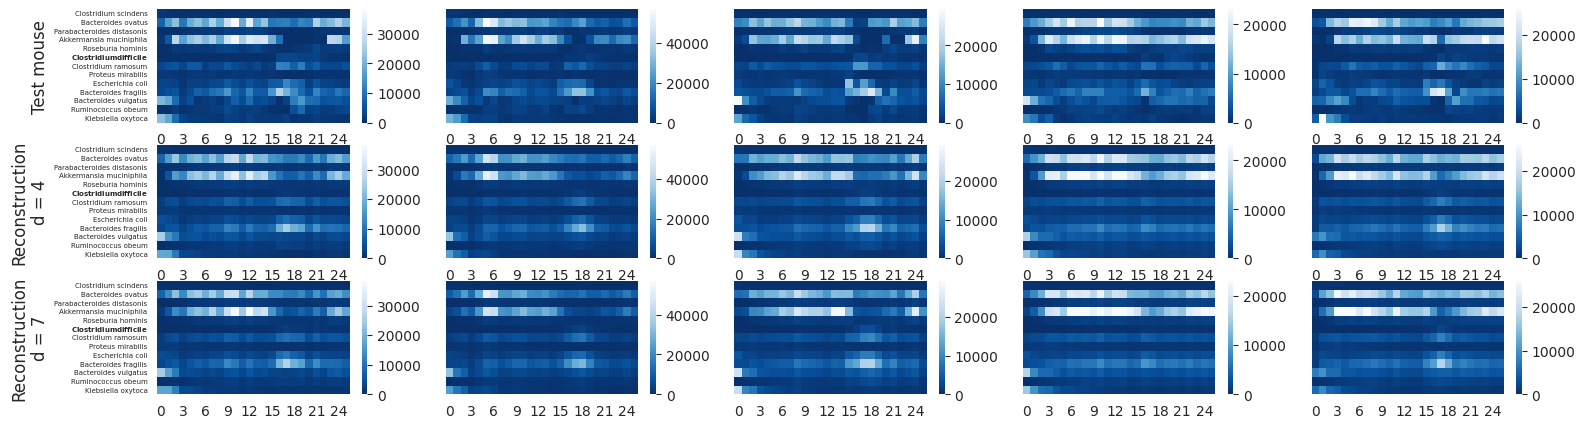

In [8]:
# Visual reconstruction
print('Reconstruction task')

d_plot = [4, 7]
fig, ax = plt.subplots(len(d_plot)+1, len(X), figsize=(18, 5), sharey=True)
cmap = 'Blues_r'
for k, d in enumerate(d_plot):
    for i, (train_index, test_index) in enumerate(loo.split(X)):
        X_test = X[test_index]
        if k == 0:
            sns.heatmap(X_test[0].T, ax=ax[0][i], cmap=cmap, linewidth=0., rasterized=True)
        
        plnica = plnica_dic[d][i].to_cpu()
        z = plnica.reconstruction(X_test, Cov=plnica.covariates[[0]], times=plnica.times[[0]])
        X_rec = torch.exp(z).detach()
    
        sns.heatmap(X_rec[0].T, ax=ax[k+1][i], cmap=cmap, vmin=X_test[0].min(), vmax=X_test.max(), linewidth=0., rasterized=True)
    ax[k+1][0].set_ylabel(f"Reconstruction\nd = {d}", fontsize=12)
    
ax[0][0].set_ylabel("Test mouse", fontsize=12)
for i in range(len(ax)):
    ax[i][0].set_yticks(np.arange(len(taxa_names))+0.5)
    ax[i][0].set_yticklabels([t.replace('-', ' ') if 'difficile' not in t else '$\\bf{'+t.replace('-', ' ')+'}$' for t in taxa_names], rotation=0, fontsize=5)
plt.savefig('./figures/reconstruction_with_d.pdf', bbox_inches='tight')

In [9]:
# Quantitative benchmark
records = {}

for d in d_list:
    metrics = {
            'Poisson deviance': [],
            'MAE log1p': [],
            'Mean Aitchison': []
        }
    for i, (train_index, test_index) in enumerate(loo.split(X)):
        X_test = X[test_index]

        plnica = plnica_dic[d][i].to_cpu()
        z = plnica.reconstruction(X_test, Cov=plnica.covariates[[0]], times=plnica.times[[0]])
        X_rec = torch.exp(z).detach()
            
        metrics['Poisson deviance'] += [average_poisson_deviance(X_test, X_rec).item()]
        metrics['MAE log1p'] += [mae_log1p(X_test, X_rec).item()]
        metrics['Mean Aitchison'] += [mean_aitchison_distance(X_test, X_rec).item()]
        
    records[f'd = {d}'] = pd.DataFrame(metrics)
records['d = 3']

,Poisson deviance,MAE log1p,Mean Aitchison
0,1045.037720,0.775512,5.118713
1,920.777161,0.619285,3.871844
2,897.261108,0.784717,4.892124
3,413.558838,0.613005,4.090661
4,816.784180,0.736255,4.420660


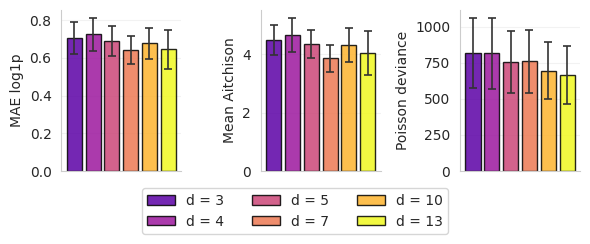

In [10]:
fig, axes = barplot_per_metric(
    records,
    ncols=3,
    ncols_legend=3,
    ylegend=-0.23,
    cmap=plt.colormaps.get_cmap('plasma'), #'viridis',
    show_xticklabels=False,  # rely on shared legend
    figsize=(6, 2)
)


plt.savefig('./figures/MDSINE_reconstruction_benchmark_dimension.pdf', bbox_inches='tight')

## Selected model

We set on a fixed $d$ and go for an in-depth analysis of the ICA.

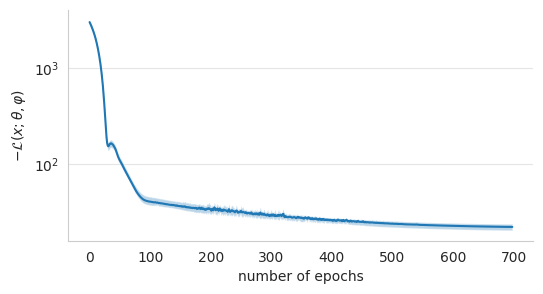

In [11]:
import torch
from plntime.models.plnica import PLNICA
import numpy as np
from sklearn.model_selection import LeaveOneOut
import matplotlib as mpl

seed=42

params = dict(
    amortized_size=10,
    n_layers_amortizer=3,
    n_output_layers_amortizer=1,
    shared_network_size=[32, 16],
    n_output_layers_shared=2
)

d = 4
C = 2

plnica_ar = {}
elbo_ar = {}

loo = LeaveOneOut()
if 'plnica_dic' in globals():
    plnica_ar = plnica_dic[d]
    elbo_ar = elbo_dic[d]
else:
    for i, (train_index, test_index) in enumerate(loo.split(X)):
        print(f"  Fold {i}:")
        plnica_ar[i] = PLNICA(
            counts=X[train_index, :, :],
            latent_size=d,
            n_dynamics=C,
            network_params=params,
            offsets='logsum',
            seed=seed,
            device='cuda',
            regularization=0.
        )
        elbo_ar[i] = plnica_ar[i].fit(n_epochs=800, weight_decay=3*1e-4, T_max=0.9)

fig, ax = plt.subplots(figsize=(6, 3))
losses = np.zeros((len(elbo_ar), 800))
for i, loss in enumerate(elbo_ar.values()):
    losses[i, :len(loss)] = loss
    losses[i, len(loss):] = np.nan
mean = np.mean(losses, axis=0)
ci_lo = np.quantile(losses, q=0.05, axis=0)
ci_hi = np.quantile(losses, q=0.95, axis=0)
ax.plot(mean)
ax.fill_between(x=np.arange(len(ci_lo)), y1=ci_lo, y2=ci_hi, alpha=0.3)
ax.set_yscale("symlog")
ax.grid(axis='x', alpha=0.)
ax.grid(axis='y', alpha=0.5)
ax.set_ylabel('$-\\mathcal{L}(x;\\theta, \\varphi)$')
ax.set_xlabel('number of epochs')
sns.despine(fig)
plt.savefig('./figures/MDSINE_ELBO_reconstruction.pdf', bbox_inches='tight')

## Components stability

First, we assess the stability of the selected model by looking at the stability of $\Gamma$.

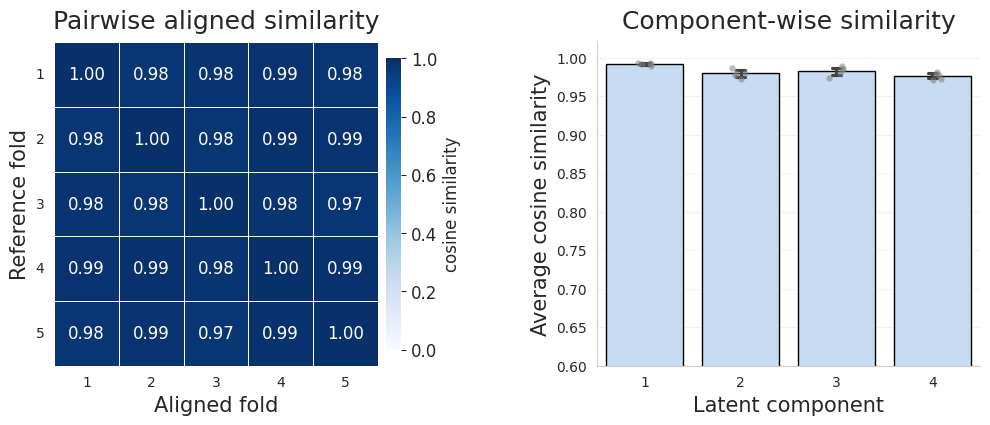

In [12]:
import warnings
warnings.filterwarnings("ignore")

# ----------------------------
# Collect Gammas (unit-norm columns)
# ----------------------------
Gamma_list = []
for i, (train_index, test_index) in enumerate(loo.split(X)):
    plnica = plnica_ar[i]
    Gamma = plnica.Gamma.normalize().detach()
    Gamma_list.append(Gamma)

n_folds = len(Gamma_list)
d = Gamma_list[0].shape[1]

# ----------------------------
# Pairwise (directed) global similarities heatmap
# ----------------------------
similarities = []
for i, G_ref in enumerate(Gamma_list):
    similarities.append([])
    for j in range(n_folds):
        plnica = plnica_ar[j]
        _, _, _, best_score = plnica.identify(G_ref)
        similarities[i].append(1 - best_score)
similarities = np.array(similarities)

# ----------------------------
# Component-wise stability (directed pairs -> aggregate within ref fold)
# ----------------------------
rows = []
for i, G_ref in enumerate(Gamma_list):
    for j in range(n_folds):
        if j == i:
            continue
        plnica = plnica_ar[j]
        G_aligned, best_perm, sign, best_score = plnica.identify(G_ref)

        cos_k = (G_ref * G_aligned).sum(dim=0).abs().detach().cpu().numpy()
        for k in range(d):
            rows.append({"component": k, "similarity": float(cos_k[k]), "ref_fold": i, "other_fold": j})

df_comp = pd.DataFrame(rows)
df_ref = (
    df_comp
    .groupby(["ref_fold", "component"], as_index=False)["similarity"]
    .mean()
)


# ----------------------------
# Combined figure
# ----------------------------
fig = plt.figure(figsize=(12.5, 4.2))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1.15, 1.0], wspace=0.35)

# --- Heatmap ---
ax0 = fig.add_subplot(gs[0, 0])
hm = sns.heatmap(
    similarities,
    vmin=0.0, vmax=1.0,
    square=True,
    annot=True, fmt=".2f",
    linewidths=0.6,
    cbar=True,
    cbar_kws={"label": "cosine similarity", "shrink": 0.9, "pad": 0.02},
    annot_kws={"fontsize": 12},
    ax=ax0,
    cmap="Blues",
)
ax0.set_title(r"Pairwise aligned similarity", pad=10, fontsize=18)
ax0.set_xlabel("Aligned fold", fontsize=15)
ax0.set_ylabel("Reference fold", fontsize=15)
ax0.set_xticks(np.arange(n_folds) + 0.5)
ax0.set_yticks(np.arange(n_folds) + 0.5)
ax0.set_xticklabels([f"{j+1}" for j in range(n_folds)], rotation=0)
ax0.set_yticklabels([f"{i+1}" for i in range(n_folds)], rotation=0)

cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("cosine similarity", fontsize=12)

# --- Barplot ---
ax1 = fig.add_subplot(gs[0, 1])

sns.barplot(
    data=df_ref,
    x="component",
    y="similarity",
    errorbar=("ci", 95),
    capsize=0.1,
    edgecolor="k",
    ax=ax1,
    color="#C0DBFA",
)
sns.stripplot(
    data=df_ref,
    x="component",
    y="similarity",
    color="grey",
    alpha=0.55,
    size=4.5,
    jitter=0.1,
    ax=ax1
)

ax1.set_title(r"Component-wise similarity", pad=10, fontsize=18)
ax1.set_xlabel("Latent component", fontsize=15)
ax1.set_ylabel("Average cosine similarity", fontsize=15)
ax1.set_ylim(0.0, 1.02)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticklabels([str(int(t.get_text()) + 1) for t in ax1.get_xticklabels()])
ax1.grid(True, axis="y", alpha=0.25)
ax1.grid(False, axis="x")
ax1.set_ylim(ymin=0.6)

plt.savefig('./figures/MDSINE_network_stability.pdf', bbox_inches='tight')

## Perturbation modeling

We look into the learnt perturbation model to see if some perturbations are expected to yield responses regarding the infection.

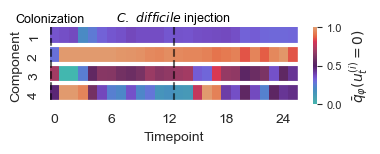

In [13]:
import cmasher as cmr
import matplotlib.colors as mcolors

alpha_bar_0 = 0
alpha_bar_ref = None
for i, (train_index, test_index) in enumerate(loo.split(X)):
    X_test = X[test_index]
    plnica = plnica_ar[i].to_cpu()
    alpha_bar = plnica.predict_vamp(X_test)['bar_alpha']
    if alpha_bar_ref is None:
        alpha_bar_ref = alpha_bar.clone()
    alpha_bar_aligned = alpha_bar.clone()
    for c in range(alpha_bar.shape[1]):
        d0 = ((alpha_bar_ref[:, c, 0] - alpha_bar[:, c, 0])**2).sum()
        d1 = ((alpha_bar_ref[:, c, 0] - 1 + alpha_bar[:, c, 0])**2).sum()
        if d0 < d1:
            alpha_bar_aligned[:, c] = alpha_bar[:, c]
        else:
            alpha_bar_aligned[:, c] = 1-alpha_bar[:, c]
    alpha_bar_0 += alpha_bar_aligned[:, :, 0]
alpha_bar_0 /= i+1
alpha_bar_0

cmap = cmr.guppy_r
cols = cmap(np.linspace(0, 1, 256))
hsv = mcolors.rgb_to_hsv(cols[:, :3])
hsv[:, 1] *= 0.75 
hsv[:, 2] *= 0.9
rgb = mcolors.hsv_to_rgb(hsv)

cmap = mcolors.ListedColormap(rgb, name=f"{cmap.name}_desat")

fig, ax = plt.subplots(figsize=(4, 1.))
sns.set_style("whitegrid")
hm = sns.heatmap(alpha_bar_0.detach().T, cmap=cmap, ax=ax, cbar_kws={'label': r'$\bar{q}_\varphi(u_t^{(i)} = 0)$'}, vmin=0., vmax=1., center=0.5, linewidths=0., rasterized=True)
cbar = hm.collections[0].colorbar
cbar.set_ticks([0., 0.5, 1.])
cbar.ax.tick_params(labelsize=8)
ax.set_ylabel("Component")
ax.set_xlabel('Timepoint')
ax.set_yticks(np.arange(d)+0.5)
ax.set_yticklabels(np.arange(d)+1)
ax.set_xticklabels([int(x) if int(x) in [0, 6, 12, 18, 24] else '' for x in ax.get_xticks()])

for i in range(d):
    ax.hlines(y=i+0.9, xmin=-1, xmax=30, color='white', linestyle='-', linewidth=3, alpha=1.)
ax.vlines(x=0.1,  ymax=d, ymin=0, color='k', linestyle='--', alpha=0.6)
ax.vlines(x=13, ymax=d, ymin=0, color='k', linestyle='--', alpha=0.6)
ax.hlines(y=i+0.9, xmin=0, xmax=26, color='white', linestyle='-', linewidth=3, alpha=1.)
ax.grid(axis='y', alpha=0.)
ax.grid(axis='x', alpha=0.)

mesh = hm.collections[0]
mesh.set_edgecolor("face")    
mesh.set_linewidth(0.0)
mesh.set_antialiased(False)
mesh.set_snap(True)

ax.text(0,  1.02, "Colonization",
        transform=ax.get_xaxis_transform(), ha='center', va='bottom',
        color='black', clip_on=False, fontsize=9)

ax.text(13, 1.01, r'$\mathit{C.\ difficile}$ injection',
        transform=ax.get_xaxis_transform(), ha='center', va='bottom',
        color='black', clip_on=False, fontsize=9)

from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((1, 0), 0, 1.1, transform=ax.transAxes,
                       fill=False, linewidth=1.0, edgecolor="w",
                       clip_on=False, zorder=10))

plt.savefig('./figures/perturbation_switch_probability.pdf', bbox_inches='tight', pad_inches=0.0)

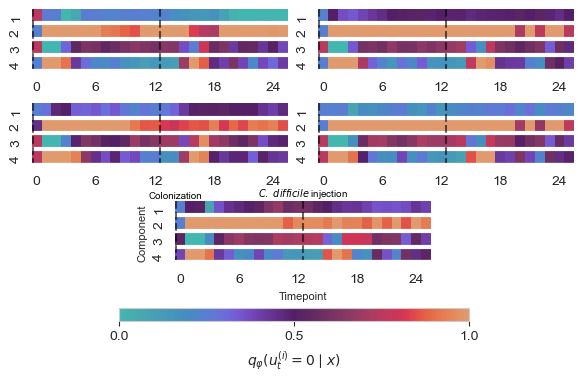

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

alphas = []
for i, (train_index, test_index) in enumerate(loo.split(X)):
    X_test = X[test_index]
    plnica = plnica_ar[i]
    alpha_bar_0 = plnica.predict_vamp(X_test)['bar_alpha'][:, :, 0]
    alphas.append(alpha_bar_0.detach().cpu())

alphas = []
alpha_bar_ref = None
for i, (train_index, test_index) in enumerate(loo.split(X)):
    X_test = X[test_index]
    plnica = plnica_ar[i].to_cpu()
    alpha_bar = plnica.predict_vamp(X_test)['bar_alpha']
    if alpha_bar_ref is None:
        alpha_bar_ref = alpha_bar.clone()
    alpha_bar_aligned = alpha_bar.clone()
    for c in range(alpha_bar.shape[1]):
        d0 = ((alpha_bar_ref[:, c, 0] - alpha_bar[:, c, 0])**2).sum()
        d1 = ((alpha_bar_ref[:, c, 0] - 1 + alpha_bar[:, c, 0])**2).sum()
        if d0 < d1:
            alpha_bar_aligned[:, c] = alpha_bar[:, c]
        else:
            alpha_bar_aligned[:, c] = 1 - alpha_bar[:, c]
    alphas.append(alpha_bar_aligned[:, :, 0])

n_plots = len(alphas)
vmin = 0
vmax = 1

# --- 2) 2-column grid ---
ncols = 2
nrows = int(np.ceil(n_plots / ncols))

fig_w = 3.5 * ncols
fig_h = 1. * nrows + 0.8
fig = plt.figure(figsize=(fig_w, fig_h))
gs = fig.add_gridspec(nrows=nrows, ncols=ncols)

sns.set_style("whitegrid")

axes = []
mappable = None
odd_last = (n_plots % 2 == 1)

for k in range(n_plots):
    r, c = divmod(k, ncols)

    ax = fig.add_subplot(gs[r, c])
    axes.append(ax)

    alpha_bar_0 = alphas[k]
    hm = sns.heatmap(
        alpha_bar_0.T,
        cmap=cmap,
        ax=ax,
        cbar=False,
        vmin=vmin, vmax=vmax,
        linewidths=0.,
        rasterized=True
    )
    mappable = hm.collections[0]

    if k == n_plots-1:
        ax.set_ylabel("Component", fontsize=8)
        ax.set_xlabel("Timepoint", fontsize=8)
    ax.set_yticks(np.arange(d) + 0.5)
    ax.set_yticklabels(np.arange(d) + 1)
    ax.set_xticklabels([int(x) if int(x) in [0, 6, 12, 18, 24] else '' for x in ax.get_xticks()])

    for i in range(d):
        ax.hlines(y=i+0.9, xmin=0, xmax=26, color='white', linestyle='-', linewidth=3, alpha=1.)
    ax.vlines(x=0.1,  ymax=d, ymin=0, color='k', linestyle='--', alpha=0.6)
    ax.vlines(x=13, ymax=d, ymin=0, color='k', linestyle='--', alpha=0.6)
    ax.hlines(y=i+0.9, xmin=0, xmax=26, color='white', linestyle='-', linewidth=3, alpha=1.)
    ax.grid(axis='y', alpha=0.)
    ax.grid(axis='x', alpha=0.)

    is_last = (k == n_plots - 1)
    if odd_last and is_last:
        ax.text(
            0, 1.02, "Colonization",
            transform=ax.get_xaxis_transform(), ha='center', va='bottom',
            color='black', clip_on=False, fontsize=7
        )
        ax.text(
            13, 1.01, r'$\mathit{C.\ difficile}$ injection',
            transform=ax.get_xaxis_transform(), ha='center', va='bottom',
            color='black', clip_on=False, fontsize=7
        )

if odd_last:
    empty_ax = fig.add_subplot(gs[nrows - 1, 1])
    empty_ax.set_visible(False)

fig.subplots_adjust(bottom=0.22, wspace=0.12, hspace=0.5)

cax = fig.add_axes([0.25, 0.06, 0.50, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label(r'$q_{\varphi}(u_t^{(i)} = 0 \mid x)$')
cbar = hm.collections[0].colorbar
cbar.set_ticks([0., 0.5, 1.])

if odd_last and n_plots >= 3:
    pos_l = axes[0].get_position()
    pos_r = axes[1].get_position()
    center_between_cols = 0.5 * ((pos_l.x0 + 0.5 * pos_l.width) + (pos_r.x0 + 0.5 * pos_r.width))

    last_ax = axes[-1]
    pos_last = last_ax.get_position()

    new_x0 = center_between_cols - 0.5 * pos_last.width
    last_ax.set_position([new_x0, pos_last.y0-0.01, pos_last.width, pos_last.height])

plt.savefig('./figures/perturbation_switch_probability_all_mice.png', bbox_inches='tight', dpi=200)

## ICA

We look into the ICA, specifically $\Gamma$ as a loading map expressing co-variations between taxa. The results are hoped to highlight biologically relevant results.

In [15]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import Normalize
import cmasher as cmr

def consensus_gamma_medoid(plnica_list, eps=1e-12, return_all=False):
    """
    Compute medoid fold based on directed pairwise similarity (row-mean),
    then align all folds to medoid and return:
      barGamma: (K, d) mean aligned Gamma, column-normalized
      tildeGamma: (K, d) std across aligned Gammas (entrywise)
      medoid_idx: int
      similarities: (F, F) numpy array
    """
    # Collect unit-norm Gammas
    Gamma_list = [plnica.Gamma.normalize().detach() for plnica in plnica_list]
    n_folds = len(Gamma_list)
    if n_folds < 2:
        raise ValueError("Need at least 2 folds to compute a medoid and std.")

    # Directed similarity heatmap
    similarities = np.zeros((n_folds, n_folds), dtype=float)
    for i, G_ref in enumerate(Gamma_list):
        for j in range(n_folds):
            plnica_j = plnica_list[j]
            _, _, _, best_score = plnica_j.identify(G_ref)
            similarities[i, j] = 1.0 - float(best_score)

    # Medoid = argmax over row mean to others (exclude diagonal)
    row_sum = similarities.sum(axis=1) - np.diag(similarities)
    row_mean = row_sum / (n_folds - 1)
    medoid_idx = int(np.argmax(row_mean))

    # Align all to medoid
    G_ref = Gamma_list[medoid_idx]
    aligned = []
    permutations = []
    for j in range(n_folds):
        plnica_j = plnica_list[j]
        G_aligned, best_perm, _, _ = plnica_j.identify(G_ref)  # (K,d), aligned to G_ref
        aligned.append(G_aligned.detach())
        permutations.append(best_perm)

    G_stack = torch.stack(aligned, dim=0)  # (F, K, d)
    mean_raw = G_stack.mean(dim=0)         # (K, d)
    std_raw = G_stack.std(dim=0, unbiased=True)  # (K, d)

    col_norm = torch.linalg.norm(mean_raw, dim=0, keepdim=True).clamp_min(eps)
    barGamma = mean_raw / col_norm
    tildeGamma = ((G_ref.unsqueeze(0) - G_stack)**2).mean(dim=0)**.5

    if return_all:
        return barGamma, tildeGamma, medoid_idx, similarities, row_mean, G_stack, permutations
    return G_ref, barGamma, tildeGamma, medoid_idx, similarities

In [16]:
def plot_loading_map(
    G_ref,
    tildeGamma,
    taxa_names,
    top_n=20,
    max_cols=3,
    figsize_per_panel=(4.2, 3.4),
    title=r"",
    sharey=False,
    cmap="RdBu_r",
    center=0.0,
    vlim=None,
    cbar_label="Mixing relative value",
    cbar_shrink=2.9,
    cbar_location="bottom", 
    ref_graph=0
):
    import pandas as pd
    import seaborn as sns

    sort_within_panel = True if sharey else False

    G = G_ref.detach().cpu().numpy()
    S = tildeGamma.detach().cpu().numpy()
    taxa_names = np.array(taxa_names, dtype=object)

    K, d = G.shape
    ncols = min(max_cols, d)
    nrows = int(np.ceil(d / ncols))

    fig_w = figsize_per_panel[0] * ncols
    fig_h = figsize_per_panel[1] * nrows

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(fig_w, fig_h),
        squeeze=False,
        sharey=sharey,
        sharex=True,
        constrained_layout=True,
    )

    if vlim is None:
        vmax = np.nanmax(np.abs(G))
        vmax = float(vmax) if np.isfinite(vmax) and vmax > 0 else 1.0
        vmin = -vmax
    else:
        vmin, vmax = float(vlim[0]), float(vlim[1])

    cmap_obj = plt.get_cmap(cmap)

    try:
        from matplotlib.colors import TwoSlopeNorm
        norm = TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
    except Exception:
        from matplotlib.colors import Normalize
        norm = Normalize(vmin=vmin, vmax=vmax)

    shared_idx = None
    if sharey:
        idx0 = np.argsort(np.abs(G[:, ref_graph]))[::-1][:top_n]
        vals0 = G[idx0, ref_graph]
        if sort_within_panel:
            order0 = np.argsort(np.abs(vals0))
            idx0 = idx0[order0]
        shared_idx = idx0
        shared_order_names = taxa_names[shared_idx]
    shared_order_names = taxa_names[shared_idx]

    for k in range(d):
        ax = axes[k // ncols][k % ncols]

        if sharey:
            idx = shared_idx
            names = shared_order_names
        else:
            idx = np.argsort(np.abs(G[:, k]))[::-1][:top_n]
            names = taxa_names[idx]
        vals = G[idx, k]
        errs = S[idx, k]
            

        colors = cmap_obj(norm(vals))

        df = pd.DataFrame(
            {"taxon": names, "value": vals, "err": errs}
        )

        order = list(names)
        df["taxon"] = pd.Categorical(df["taxon"], categories=order, ordered=True)

        df["_hue_taxon"] = df["taxon"]
        palette = {n: c for n, c in zip(order, colors)}

        sns.barplot(
            data=df,
            y="taxon",
            x="value",
            order=order,
            hue="_hue_taxon",
            palette=palette,
            legend=False,
            ax=ax,
            orient="h",
            edgecolor="k",
            width=1.,
            linewidth=1,
            alpha=1.,
        )

        patches = list(ax.patches)
        y_centers = np.array([p.get_y() + 0.5 * p.get_height() for j, p in enumerate(patches)], dtype=float)
        x_vals = np.array([p.get_width() for p in patches], dtype=float)

        ax.errorbar(
            x=x_vals,
            y=y_centers,
            xerr=errs,
            fmt="none",
            ecolor="k",
            elinewidth=0.8,
            capsize=2,
            capthick=0.8,
            zorder=5,
        )

        ax.axvline(0.0, linewidth=1.0, color="k", alpha=0.8)

        ax.set_xticks([])
        ax.set_ylabel('')

        ax.set_yticks(y_centers)
        ax.set_yticklabels(order, fontsize=13)

        ax.set_title(f"Component {k+1}", pad=6, fontsize=17)
        ax.grid(True, axis="x", alpha=0.2)
        ax.grid(True, axis="y", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if sharey and (k % ncols) != 0:
            ax.set_ylabel("")
            ax.tick_params(axis="y", labelleft=False)
        ax.set_xlabel('')

    for k in range(d, nrows * ncols):
        axes[k // ncols][k % ncols].axis("off")

    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])

    if cbar_location == "bottom":
        cbar = fig.colorbar(
                sm,
                ax=axes.ravel().tolist(),
                location="bottom",
                shrink=cbar_shrink,
                pad=0.06,
                fraction=0.1,
            )
        cbar.set_label(cbar_label, fontweight='bold', fontsize=17)
    else:
        cbar = fig.colorbar(
            sm,
            ax=axes.ravel().tolist(),
            location="right" if "location" in fig.colorbar.__code__.co_varnames else None,
            shrink=cbar_shrink,
            pad=0.02,
            fraction=0.035,
        )
        cbar.set_label(cbar_label, fontsize=14)

    if title:
        fig.suptitle(title)

    labels = []
    for x in axes[0][0].get_yticklabels():
        lbl = x.get_text().split('-')[0][0] + '. ' + x.get_text().split('-')[1]
        if x.get_text() == 'Clostridium-difficile':
            lbl = '$\\bf{' + lbl + '}$'
        else:
            lbl = '$\\rm{' + lbl + '}$'
        labels += [lbl]
    axes[0][0].set_yticklabels(labels)

    return fig, axes

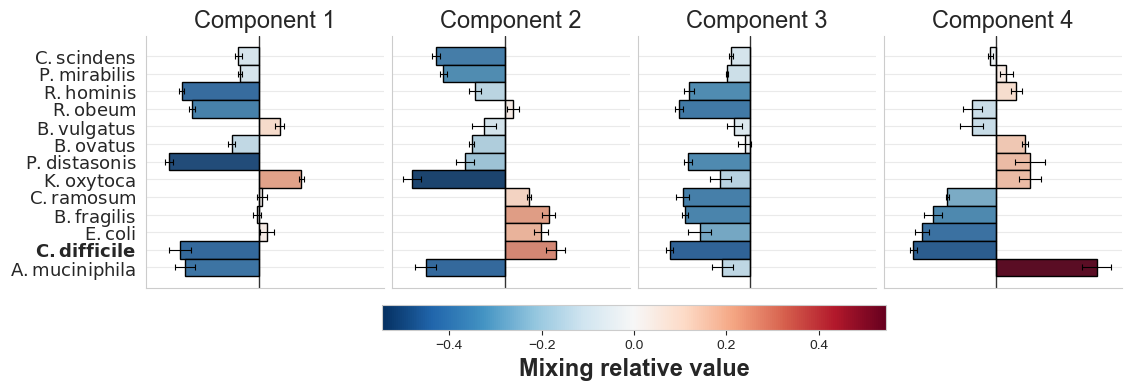

In [17]:
G_ref, barGamma, tildeGamma, medoid_idx, similarities = consensus_gamma_medoid(list(plnica_ar.values()))

taxa_names = list(longitudinal_data.columns[2:]) 
fig2, axes2 = plot_loading_map(
    G_ref, tildeGamma,
    taxa_names=taxa_names,
    top_n=20,
    max_cols=d,
    sharey=True,
    figsize_per_panel=(2.8, 3.8),
    ref_graph=3
)

plt.savefig(f'./figures/component-wise_interactions_MDSINE_d_{d}.pdf')

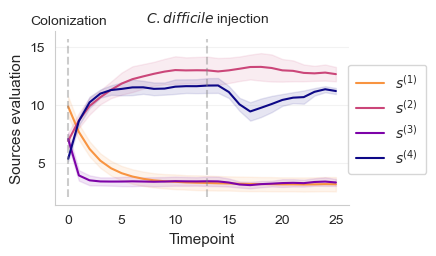

In [18]:
fig, ax = plt.subplots(figsize=(3.8, 3))

signals = []
for i, (train_index, test_index) in enumerate(loo.split(X)):
    
    X_test = X[test_index]
    plnica = plnica_ar[i]
    
    latent_params = plnica.forward(X_test, O=torch.log(X_test.sum(dim=-1, keepdim=False) + 1), Cov=plnica.covariates[[0]], times=plnica.times[[0]])
    expectations = plnica.E_step(latent_params)
    mu = expectations['mu'].detach()
    signals.append(mu)

signals = torch.cat(signals)
signals_mean = signals.mean(dim=0)
signals_std = signals.std(dim=0)

cmap = plt.colormaps.get_cmap('plasma_r')
colors = {
    i: cmap((i+1)/signals.shape[-1]) for i in range(signals.shape[-1])
}

for i in range(signals.shape[-1]):
    ax.plot(signals_mean[:, i], color=colors[i], label='$s^{('+str(i+1)+')}$')
    ax.fill_between(np.arange(signals.shape[1]), signals_mean[:, i] - signals_std[:, i], signals_mean[:, i] + signals_std[:, i], color=colors[i], alpha=0.1)

ax.grid(axis='x', alpha=0)
ax.grid(axis='y', alpha=0.25)
ax.vlines(x=13, color='grey', linestyle='--', ymax=signals.max()+.5, ymin=signals.min()-0.5, alpha=0.4)
ax.text(
    13, 1.02, "$\\mathit{C. difficile}$ injection",
    transform=ax.get_xaxis_transform(),
    ha='center', va='bottom', fontsize=10
)
ax.vlines(x=0, color='grey', linestyle='--', ymax=signals.max()+.5, ymin=signals.min()-0.5, alpha=0.4)
ax.text(
    0, 1.02, "Colonization",
    transform=ax.get_xaxis_transform(), 
    ha='center', va='bottom', fontsize=10
)
ax.set_ylabel('Sources evaluation', fontsize=11)
ax.set_xlabel('Timepoint', fontsize=11)

fig.subplots_adjust(bottom=0.30)  
fig.legend(
    loc="lower center",
    #bbox_to_anchor=(0.5, -0.15),
    bbox_to_anchor=(0.5+0.5, 0.38),
    ncol=1,#min(signals.shape[-1], 4),
    frameon=True,
    borderpad=0.6,
    handlelength=2.0
)

sns.despine(fig)
plt.savefig(f'./figures/sources_along_time_d_{d}.pdf', bbox_inches='tight')

# Forecasting

We assess the capabilities of our model on an auxiliary forecasting benchmark.

## Effect of the number of sources

In [19]:
import torch
from plntime.models.plnica import PLNICA
import numpy as np
from sklearn.model_selection import LeaveOneOut
import matplotlib as mpl
import pickle
import os

seed=42

params = dict(
    amortized_size=10,
    n_layers_amortizer=3,
    n_output_layers_amortizer=1,
    shared_network_size=[32, 16],
    n_output_layers_shared=2
)

d_list = [3, 4, 5, 7, 10, 13]
C = 2

plnica_dic = {}
elbo_dic = {}
loo = LeaveOneOut()

path_plnica = './cache/forecasting/plnica_ar_dic.pkl'
path_elbo = './cache/forecasting/elbo_ar_dic.pkl'
if os.path.isfile(path_plnica):
    print('loaded')
    with open(path_plnica, 'rb') as f:
        plnica_dic = pickle.load(f)
    with open(path_elbo, 'rb') as f:
        elbo_dic = pickle.load(f)
else:
    for d in d_list:
        print('Dimension', d)
        plnica_dic[d] = {}
        elbo_dic[d] = {}
        for i, (train_index, test_index) in enumerate(loo.split(X)):
            print(f"  Fold {i}:")
            plnica_dic[d][i] = PLNICA(
                counts=X[train_index, :, :],
                latent_size=d,
                n_dynamics=C,
                network_params=params,
                offsets='logsum',
                predictive=True,
                seed=seed,
                device='cuda',
            )
            elbo_dic[d][i] = plnica_dic[d][i].fit(n_epochs=800, weight_decay=3*1e-4, T_max=0.9)
    
    print('saved')
    with open(path_plnica, 'wb') as f:
        pickle.dump(plnica_dic, f)
    with open(path_elbo, 'wb') as f:
        pickle.dump(elbo_dic, f)

loaded


Forecasting task


Text(197.72222222222223, 0.5, 'Test mouse')

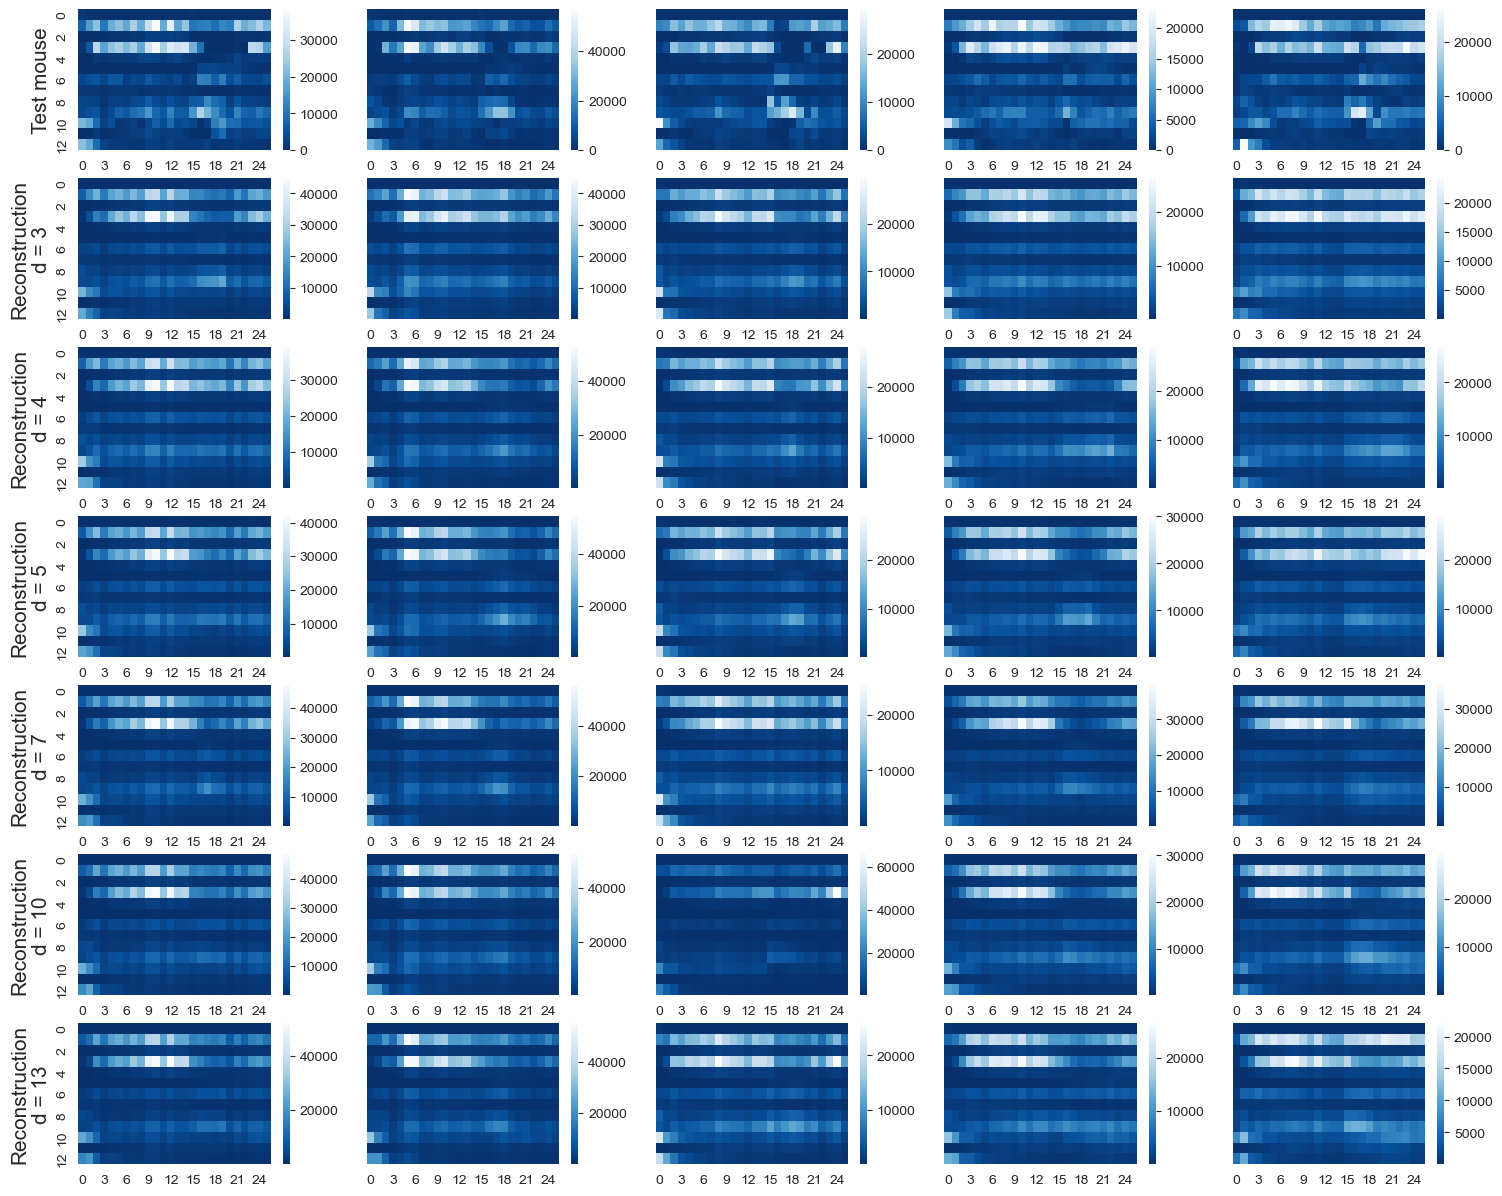

In [20]:
# Visual reconstruction
print('Forecasting task')

t_start = 2

fig, ax = plt.subplots(len(d_list)+1, len(X), figsize=(18, 15), sharey=True)
cmap = 'Blues_r'
for k, d in enumerate(d_list):
    for i, (train_index, test_index) in enumerate(loo.split(X)):
        X_test = X[test_index]
        if k == 0:
            sns.heatmap(X_test[0].T, ax=ax[0][i], cmap=cmap)
        
        plnica = plnica_dic[d][i].to_cpu()
        X_pred = plnica.predict_vamp(X_test[:, :t_start], O=torch.log(X_test.sum(dim=-1, keepdim=False) + 1))['prediction']
    
        sns.heatmap(X_pred[0].T, ax=ax[k+1][i], cmap=cmap, vmin=X_pred[0].min(), vmax=X_pred.max())
    ax[k+1][0].set_ylabel(f"Reconstruction\nd = {d}", fontsize=15)
    
ax[0][0].set_ylabel("Test mouse", fontsize=15)

In [21]:
# Quantitative benchmark
records = {}

for d in d_list:
    metrics = {
            'Poisson deviance': [],
            'MAE log1p': [],
            'Mean Aitchison': []
        }
    for i, (train_index, test_index) in enumerate(loo.split(X)):
        X_test = X[test_index]

        plnica = plnica_dic[d][i].to_cpu()
        X_pred = plnica.predict_vamp(X_test[:, :t_start], O=torch.log(X_test.sum(dim=-1, keepdim=False) + 1))['prediction']
            
        metrics['Poisson deviance'] += [average_poisson_deviance(X_test, X_pred).item()]
        metrics['MAE log1p'] += [mae_log1p(X_test, X_pred).item()]
        metrics['Mean Aitchison'] += [mean_aitchison_distance(X_test, X_pred).item()]
        
    records[f'd = {d}'] = pd.DataFrame(metrics)
records['d = 3']

,Poisson deviance,MAE log1p,Mean Aitchison
0,1191.994629,0.804042,5.236098
1,1509.813843,0.670957,4.175568
2,1198.648804,0.814573,5.044693
3,449.190643,0.637009,4.251310
4,926.877197,0.765310,4.468818


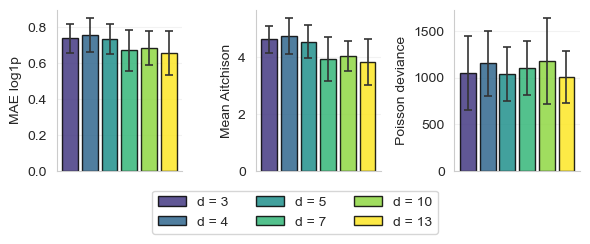

In [22]:
fig, axes = barplot_per_metric(
    records,
    ncols=3,
    ncols_legend=3,
    ylegend=-0.23,
    cmap=plt.colormaps.get_cmap('viridis'), 
    show_xticklabels=False, 
    figsize=(6, 2)
)

plt.savefig('./figures/MDSINE_forecasting_benchmark_dimension.pdf', bbox_inches='tight')

## Selected model

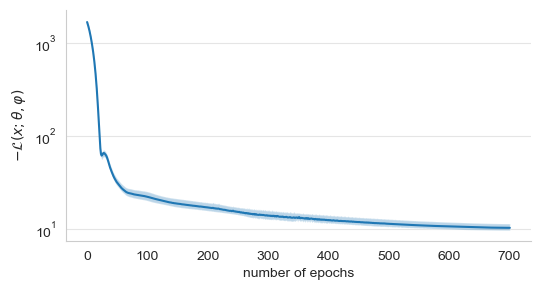

In [23]:
import torch
from plntime.models.plnica import PLNICA
import numpy as np
from sklearn.model_selection import LeaveOneOut
import matplotlib as mpl

seed=42

params = dict(
    amortized_size=10,
    n_layers_amortizer=3,
    n_output_layers_amortizer=1,
    shared_network_size=[32, 16],
    n_output_layers_shared=2
)

d = 7
C = 2

plnica_predictive_ar = {}
elbo_predictive_ar = {}

loo = LeaveOneOut()
if 'plnica_dic' in globals():
    plnica_predictive_ar = plnica_dic[d]
    elbo_predictive_ar = elbo_dic[d]
else:
    for i, (train_index, test_index) in enumerate(loo.split(X)):
        print(f"  Fold {i}:")
        plnica_predictive_ar[i] = PLNICA(
            counts=X[train_index, :, :],
            latent_size=d,
            n_dynamics=C,
            network_params=params,
            predictive=True,
            offsets='logsum',
            seed=seed,
            device='cuda',
        )
        elbo_predictive_ar[i] = plnica_ar[i].fit(n_epochs=800, weight_decay=3*1e-4, T_max=0.9)

fig, ax = plt.subplots(figsize=(6, 3))
losses = np.zeros((len(elbo_predictive_ar), 800))
for i, loss in enumerate(elbo_predictive_ar.values()):
    losses[i, :len(loss)] = loss
    losses[i, len(loss):] = np.nan
mean = np.mean(losses, axis=0)
ci_lo = np.quantile(losses, q=0.05, axis=0)
ci_hi = np.quantile(losses, q=0.95, axis=0)
ax.plot(mean)
ax.fill_between(x=np.arange(len(ci_lo)), y1=ci_lo, y2=ci_hi, alpha=0.3)
ax.set_yscale("symlog")
ax.grid(axis='x', alpha=0.)
ax.grid(axis='y', alpha=0.5)
ax.set_ylabel('$-\\mathcal{L}(x;\\theta, \\varphi)$')
ax.set_xlabel('number of epochs')
sns.despine(fig)
plt.savefig('./figures/MDSINE_ELBO_forecasting.pdf', bbox_inches='tight')

## Benchmark

Fold 0:


 88%|████████▊ | 701/800 [02:43<00:23,  4.29it/s, Loss=37.6, Status=Converged]                                         


Fold 1:


 88%|████████▊ | 703/800 [02:58<00:24,  3.94it/s, Loss=39.6, Status=Converged]                                         


Fold 2:


 88%|████████▊ | 704/800 [02:37<00:21,  4.47it/s, Loss=42.9, Status=Converged]                                         


Fold 3:


 88%|████████▊ | 705/800 [02:23<00:19,  4.91it/s, Loss=45.1, Status=Converged]                                         


Fold 4:


 88%|████████▊ | 706/800 [02:58<00:23,  3.95it/s, Loss=40.7, Status=Converged]                                         


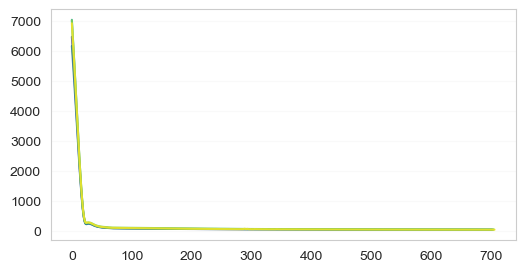

In [24]:
# Homogeneous model, C=1
fig, ax = plt.subplots(figsize=(6, 3))

plnica_predictive_ar_homogeneous = {}

loo = LeaveOneOut()
for i, (train_index, test_index) in enumerate(loo.split(X)):
    print(f"Fold {i}:")
    plnica_predictive_ar_homogeneous[i] = PLNICA(
        counts=X[train_index, :, :],
        latent_size=d,
        n_dynamics=1,
        network_params=params,
        offsets='logsum',
        predictive=True,
        seed=seed,
        device='cuda',
    )
    losses = plnica_predictive_ar_homogeneous[i].fit(n_epochs=800, weight_decay=3*1e-4, T_max=0.9)
    ax.plot(np.arange(len(losses)), losses, color=mpl.colormaps.get_cmap('viridis')((i+1)/len(X)), alpha=0.8)

ax.grid(axis='x', alpha=0.)
ax.grid(axis='y', alpha=0.1)

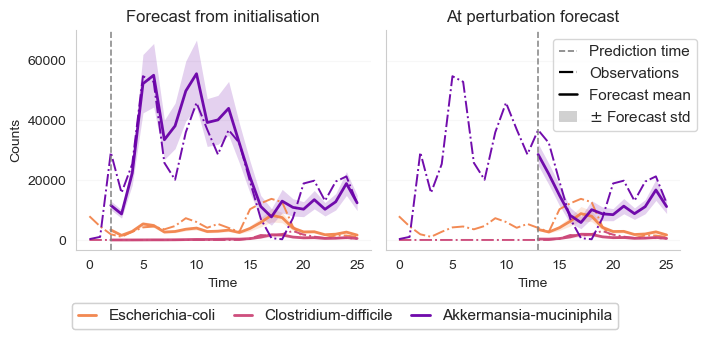

In [25]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def mean_var_to_proportions(mean_counts, var_counts, eps=1e-12):
    m = mean_counts.clamp_min(eps)
    v = var_counts.clamp_min(0.0)

    S = m.sum(dim=-1, keepdim=True).clamp_min(eps)   # (T, 1)
    mean_prop = m / S

    var_S = v.sum(dim=-1, keepdim=True)              # (T, 1)

    var_prop = (
        v / (S ** 2)
        + (m ** 2) * var_S / (S ** 4)
        - 2.0 * m * v / (S ** 3)
    ).clamp_min(0.0)

    return mean_prop, var_prop


def _resolve_taxa_selection(taxa_dict, taxa_names, K):
    if taxa_dict is None:
        return None, None, None

    if taxa_names is None:
        taxa_names = [f"taxon {j+1}" for j in range(K)]
    name_to_idx = {str(n): j for j, n in enumerate(taxa_names)}

    idx, cols, labels = [], [], []
    for key, col in taxa_dict.items():
        if isinstance(key, (int, np.integer)):
            j = int(key)
            if not (0 <= j < K):
                raise ValueError(f"Taxon index {j} out of bounds (K={K}).")
            idx.append(j)
            labels.append(str(taxa_names[j]))
            cols.append(col)
        else:
            k = str(key)
            if k not in name_to_idx:
                raise ValueError(f"Taxon name '{k}' not found in taxa_names.")
            j = int(name_to_idx[k])
            idx.append(j)
            labels.append(k)
            cols.append(col)

    return np.array(idx, dtype=int), cols, labels


def plot_forecast_mean_std(
    X_true,
    mean_counts,
    var_counts,
    t_start,
    taxa_names=None,
    top_k=12,
    select_by="true_mean",
    space="proportion",
    sd_mult=1.0,
    cmap="tab20",
    linewidth_true=1.4,
    linewidth_pred=2.0,
    band_alpha=0.18,
    true_style="-.",
    pred_style="-",
    title=None,
    ax=None,
    eps=1e-12,
    ylabel=None,
    taxa_dict=None,
    return_handles=False,
):
    assert X_true.dim() == 2
    T, K = X_true.shape

    if taxa_names is None:
        taxa_names = [f"taxon {j+1}" for j in range(K)]

    forced_idx, forced_cols, forced_labels = _resolve_taxa_selection(taxa_dict, taxa_names, K)

    if forced_idx is not None:
        idx = forced_idx
        colors = forced_cols
        labels = forced_labels
    else:
        if select_by == "true_mean":
            score = X_true.mean(dim=0)
        elif select_by == "forecast_mean":
            score = mean_counts.mean(dim=0)
        else:
            raise ValueError("select_by must be 'true_mean' or 'forecast_mean'")

        idx = torch.topk(score, k=min(top_k, K)).indices.detach().cpu().numpy()
        colors = plt.get_cmap(cmap)(np.linspace(0, 1, len(idx)))
        labels = [str(taxa_names[j]) for j in idx]

    if space == "proportion":
        true_prop = X_true / X_true.sum(dim=-1, keepdim=True).clamp_min(eps)
        mean_prop, var_prop = mean_var_to_proportions(mean_counts, var_counts, eps=eps)
        y_true = true_prop[:, idx]
        y_mean = mean_prop[:, idx]
        y_sd = torch.sqrt(var_prop[:, idx].clamp_min(0.0))
        ylab = "Relative abundance"
    elif "count" in space:
        y_true = X_true[:, idx]
        y_mean = mean_counts[:, idx]
        y_sd = torch.sqrt(var_counts[:, idx].clamp_min(0.0))
        ylab = "Counts"
    else:
        raise ValueError("space must be 'proportion' or contain 'count'")

    if ylabel is not None:
        ylab = ylabel

    lo = y_mean - sd_mult * y_sd
    hi = y_mean + sd_mult * y_sd
    if space == "proportion":
        lo = lo.clamp(0.0, 1.0)
        hi = hi.clamp(0.0, 1.0)
    else:
        lo = lo.clamp_min(0.0)
        hi = hi.clamp_min(0.0)

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.2))

    x = np.arange(T)
    xf = np.arange(t_start, T)

    handles = []
    for c, j in enumerate(idx):
        col = colors[c]
        name = labels[c]

        ax.plot(
            x,
            y_true[:, c].detach().cpu().numpy(),
            true_style,
            color=col,
            linewidth=linewidth_true,
            alpha=0.95,
        )

        (line_pred,) = ax.plot(
            x[t_start:],
            y_mean[t_start:, c].detach().cpu().numpy(),
            pred_style,
            color=col,
            linewidth=linewidth_pred,
            alpha=0.95,
            label=name,
        )
        handles.append(line_pred)

        ax.fill_between(
            xf,
            lo[t_start:, c].detach().cpu().numpy(),
            hi[t_start:, c].detach().cpu().numpy(),
            color=col,
            alpha=band_alpha,
            linewidth=0.0,
        )

    ax.axvline(t_start, color="grey", linestyle="--", linewidth=1.2, alpha=0.9)
    ax.set_xlabel("Time")
    ax.set_ylabel(ylab)
    if title is not None:
        ax.set_title(title, pad=6)

    ax.grid(axis="x", alpha=0.0)
    ax.grid(True, axis="y", alpha=0.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if return_handles:
        return ax, idx, handles, labels
    return ax, idx


def plot_loocv_forecasts(
    X, loo, plnica_predictive_ar,
    mouse=0,
    t_start_1=5,
    t_start_2=12,
    Cov_for_test=None,
    times_for_test=None,
    taxa_names=None,
    top_k=12,
    space="proportion",
    cmap="tab20",
    figsize=(18, 3.6),
    taxa_dict=None,
    legend_ncol=6,
    legend_fontsize=9,
    legend_y=-0.02,
    style_legend=True,
    style_legend_fontsize=None,
    style_legend_ncol=1,
    style_legend_dx=0.18,  
    style_legend_dy=0.,
    band_alpha=0.18,
    true_style="-.",
    pred_style="-",
):
    n_folds = len(X)
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True, sharex=True)

    if n_folds == 1:
        axes = [axes]

    global_handles = None
    global_labels = None

    for i, (train_index, test_index) in enumerate(loo.split(X)):
        if i != mouse:
            continue
        X_test = X[test_index]
        plnica = plnica_predictive_ar[i].to_cpu()
        T_total = X_test.shape[1]

        if Cov_for_test is None:
            Cov_i = plnica.covariates[[0]]
        else:
            Cov_i = Cov_for_test[i]

        if times_for_test is None:
            times_i = plnica.times[[0]]
        else:
            times_i = times_for_test[i]

        out_1 = plnica.predict_vamp(
            X_test[:, :t_start_1, :],
            O=torch.log(X_test.sum(dim=-1, keepdim=False) + 1),
        )

        out_2 = plnica.predict_vamp(
            X_test[:, :t_start_2, :],
            O=torch.log(X_test.sum(dim=-1, keepdim=False) + 1),
        )

        ax = axes[0]
        ax, idx, handles, labels = plot_forecast_mean_std(
            X_true=X_test[0],
            mean_counts=out_1["prediction"][0],
            var_counts=out_1["variance"][0],
            t_start=t_start_1,
            taxa_names=taxa_names,
            top_k=top_k,
            select_by="true_mean",
            space=space,
            cmap=cmap,
            title=f"Mouse {i+1}",
            ax=ax,
            taxa_dict=taxa_dict,
            return_handles=True,
        )

        ax = axes[1]
        ax, idx, handles, labels = plot_forecast_mean_std(
            X_true=X_test[0],
            mean_counts=out_2["prediction"][0],
            var_counts=out_2["variance"][0],
            t_start=t_start_2,
            taxa_names=taxa_names,
            top_k=top_k,
            select_by="true_mean",
            space=space,
            cmap=cmap,
            title=f"Mouse {i+1}",
            ax=ax,
            taxa_dict=taxa_dict,
            return_handles=True,
        )

        if global_handles is None:
            global_handles = handles
            global_labels = labels
        ax.set_ylabel('')

    axes[0].set_ylabel("Relative abundance" if space == "proportion" else "Counts")
    axes[0].set_title('Forecast from initialisation')
    axes[1].set_title('At perturbation forecast')
    
    fig.tight_layout(rect=[0.0, 0.14, 1.0, 1.0])

    leg1 = None
    if global_handles is not None and global_labels is not None:
        leg1 = fig.legend(
            global_handles,
            global_labels,
            loc="lower center",
            bbox_to_anchor=(0.5, legend_y),
            ncol=min(int(legend_ncol), len(global_labels)),
            frameon=True,
            fontsize=legend_fontsize,
            handlelength=1.2,
            columnspacing=1.2,
        )

    if style_legend:
        if style_legend_fontsize is None:
            style_legend_fontsize = legend_fontsize

        style_handles = [
            Line2D([0], [0], color="grey", linestyle="--", linewidth=1.2, label="Prediction time"),
            Line2D([0], [0], color="black", linestyle=true_style, linewidth=1.6, label="Observations"),
            Line2D([0], [0], color="black", linestyle=pred_style, linewidth=1.8, label="Forecast mean"),
            Patch(facecolor="black", edgecolor="none", alpha=band_alpha, label=r"$\pm$ Forecast std"),
        ]

        leg2 = fig.legend(
            handles=style_handles,
            loc="lower center",
            bbox_to_anchor=(0.5 + style_legend_dx/2, legend_y + style_legend_dy),
            ncol=int(style_legend_ncol),
            frameon=True,
            fontsize=style_legend_fontsize,
            handlelength=1.2,
            columnspacing=1.2,
        )

        if leg1 is not None:
            fig.add_artist(leg1)

    return fig, axes

import cmasher

taxa_names = longitudinal_data.columns[2:]

taxa_dict = {
    'Escherichia-coli': plt.colormaps.get_cmap('plasma')(0.7),
    'Clostridium-difficile': plt.colormaps.get_cmap('plasma')(0.5),
    'Akkermansia-muciniphila': plt.colormaps.get_cmap('plasma')(0.2)
}

plot_loocv_forecasts(
    X, loo, plnica_predictive_ar,
    mouse=1,
    t_start_1=2,
    t_start_2=13,
    taxa_names=taxa_names,
    top_k=12,
    taxa_dict=taxa_dict,
    space="count",
    cmap="Set2",
    figsize=(7, 3.6),
    legend_fontsize=11,
    legend_y=0.05,
    legend_ncol=3,
    style_legend=True,
    style_legend_ncol=1,
    style_legend_dx=0.8,
    style_legend_dy=0.55,
    true_style="-.",
    pred_style="-",
    band_alpha=0.18,
)

plt.savefig('./figures/MDSINE_forecasts.pdf', bbox_inches='tight')

In [26]:
# Models benchmark

from baselines.var_baseline import VAR1
from baselines.ica_baseline import BatchedUwedgeICA, BatchedPicardICA
from baselines.lokta_volterra import *
import random

records = {}

for t_start in range(2, 21):
    print('t_0', t_start)
    models = {
        'ARPLN-ICA': [],
        '(h)-ARPLN-ICA': [],
        'CLR-VAR(1)': [],
        'CLR-UwedgeICA': [],
        'CLR-Picard': [],
        'gLV-L2': []
    }

    for model in models.keys():
        metrics = {
            'Poisson deviance': [],
            'MAE log1p': [],
            'Mean Aitchison': []
        }
        for i, (train_index, test_index) in enumerate(loo.split(X)):

            random.seed(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)
            
            X_train = X[train_index]
            X_test = X[test_index]
            
            if 'ARPLN-ICA' in model:
                if '(h)' in model:
                    plnica = plnica_predictive_ar_homogeneous[i]
                else:
                    plnica = plnica_predictive_ar[i]
                
                X_pred = plnica.to_cpu().predict_vamp(
                    X_test[:, :t_start],
                    O=torch.log(X_test.sum(dim=-1, keepdim=False) + 1),
                )['prediction']
                X_pred[:, :t_start] = X_test[:, :t_start]
            elif model == 'CLR-VAR(1)':
                var = VAR1().fit(clr(X_train))
                X_pred = var.predict(clr(X_test[:, :t_start]).detach().numpy())
                X_pred[:, :t_start] = clr(X_test[:, :t_start]).detach().numpy()
                O = offset(X_test)
                X_pred = torch.softmax(torch.tensor(X_pred), dim=-1) * torch.exp(O).unsqueeze(-1)
                X_pred[:, :t_start] = X_test[:, :t_start]

            elif model == 'CLR-UwedgeICA':
                sobi = BatchedUwedgeICA(
                    d=plnica.d,
                    window=10,
                    lags=np.arange(1, 9),
                    step=10,
                    instantcov=True,    
                ).fit(clr(X_train))
                Z_train = sobi.transform(clr(X_train))
                var = VAR1().fit(Z_train)
    
                Z_test = sobi.transform(clr(X_test[:, :t_start]))
                Z_pred = var.predict(Z_test)
                O = offset(X_test)
                X_pred = torch.softmax(torch.tensor(sobi.inverse_transform(Z_pred)), dim=-1) * torch.exp(O).unsqueeze(-1)
                X_pred[:, :t_start] = X_test[:, :t_start]

            elif model == 'CLR-Picard':
                sobi = BatchedPicardICA(
                    d=plnica.d,
                ).fit(clr(X_train))
                Z_train = sobi.transform(clr(X_train))
                var = VAR1().fit(Z_train)
    
                Z_test = sobi.transform(clr(X_test[:, :t_start]))
                Z_pred = var.predict(Z_test)
                O = offset(X_test)
                X_pred = torch.softmax(torch.tensor(sobi.inverse_transform(Z_pred)), dim=-1) * torch.exp(O).unsqueeze(-1)
                X_pred[:, :t_start] = X_test[:, :t_start]
    
            elif model == 'gLV-L2':
                times = metadata.measurementid.sort_values().unique()
                lib_train = X_train.numpy().sum(axis=-1, keepdims=True)
                scale = np.median(lib_train[lib_train > 0]) if np.any(lib_train > 0) else 1.0
            
                def normalize(Y):
                    lib = Y.sum(axis=-1, keepdims=True)
                    Y = Y / np.maximum(lib, 1.0) * scale
                    return Y + 1.0
            
                X_train_n = normalize(X_train.numpy())
                X_test_n  = normalize(X_test.numpy())
            
                predictor = fit_glv_ridge_batch(X_train_n, times=times)[0]
            
                X_pred_n = forecast_mean_from_prefix(predictor, X_test_n[0, :t_start, :], times)  # (T, K)
    
                L_test = X_test[0].numpy().sum(axis=-1, keepdims=True)  # (T, 1)
            
                X_pred_comp = np.maximum(X_pred_n - 1.0, 0.0)
                P_pred = X_pred_comp / np.maximum(X_pred_comp.sum(axis=-1, keepdims=True), 1e-12)  # (T, K)
            
                X_pred = torch.tensor(P_pred * L_test)  # (T, K) predicted counts using true offsets
        
            metrics['Poisson deviance'] += [average_poisson_deviance(X_test, X_pred).item()]
            metrics['MAE log1p'] += [mae_log1p(X_test, X_pred).item()]
            metrics['Mean Aitchison'] += [mean_aitchison_distance(X_test, X_pred).item()]
        
        metrics = pd.DataFrame(metrics)
        models[model] = metrics
    records[t_start] = models

t_0 2
minimum found: a0/a1/error: 1.0 1.0 1.1226910540865314
unconstrained error        : 3.433157002212553
minimum found: a0/a1/error: 0.01 1.0 1.1740550623951895
unconstrained error        : 1.7124443286104796
minimum found: a0/a1/error: 1.0 1.0 1.1201229192596402
unconstrained error        : 1.656609477587476
minimum found: a0/a1/error: 1.0 1.0 1.1222722060343497
unconstrained error        : 2.8889225653690263
minimum found: a0/a1/error: 0.01 0.001 0.8504323712356081
unconstrained error        : 1.0375885475940172
t_0 3
minimum found: a0/a1/error: 1.0 1.0 1.1226910540865314
unconstrained error        : 3.433157002212553
minimum found: a0/a1/error: 0.01 1.0 1.1740550623951895
unconstrained error        : 1.7124443286104796
minimum found: a0/a1/error: 1.0 1.0 1.1201229192596402
unconstrained error        : 1.656609477587476
minimum found: a0/a1/error: 1.0 1.0 1.1222722060343497
unconstrained error        : 2.8889225653690263
minimum found: a0/a1/error: 0.01 0.001 0.8504323712356081
un

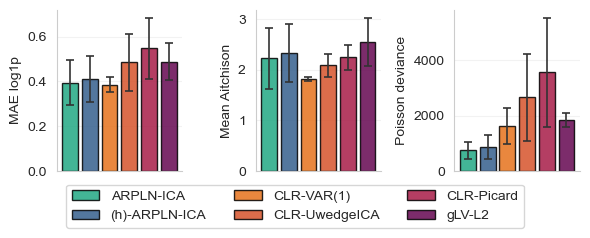

In [27]:
metrics = {}
for t in records.keys():
    for model in records[t].keys():
        if model not in metrics:
            metrics[model] = records[t][model] / len(records.keys())
        else:
            metrics[model] += records[t][model] / len(records.keys())

cmap = cmasher.pride
model_colors = {
    'ARPLN-ICA': plt.colormaps.get_cmap('viridis')(0.6), 
    '(h)-ARPLN-ICA': plt.colormaps.get_cmap('viridis')(0.3), 
    'CLR-VAR(1)': cmap(0.65), 
    'CLR-UwedgeICA': cmap(0.7),
    'CLR-Picard': cmap(0.8), 
    'gLV-L2': cmap(0.9), 
}

fig, axes = barplot_per_metric(
    metrics,
    model_colors=model_colors,
    ncols=3,
    show_xticklabels=False, 
    ylegend=-0.2,
    ncols_legend=3,
    figsize=(6, 2)
)
sns.despine(fig)

plt.savefig('./figures/MDSINE_forecast_benchmark.pdf', bbox_inches='tight')